In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lsind18/gemstones-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gemstones-images' dataset.
Path to dataset files: /kaggle/input/gemstones-images


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpu_name = tf.test.gpu_device_name()
if gpu_name != '/device:GPU:0':
    print(f'\nWARNING: GPU not found or not configured correctly. Found: {gpu_name}')
else:
    print(f'\nFound GPU at: {gpu_name}')

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("\nPhysical GPUs:", physical_devices)
    for gpu in physical_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth set for GPUs.")
else:
    print("\nNo physical GPUs found.")

TensorFlow version: 2.20.0

Found GPU at: /device:GPU:0

Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth set for GPUs.


In [ ]:
import os
import tensorflow as tf

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# The 'path' variable from the previous cell points to '/kaggle/input/gemstones-images'
base_data_dir = path

# Define validation split and seed for reproducibility
VAL_SPLIT = 0.2
SEED = 42

# Path to the directory containing the images (e.g., '/kaggle/input/gemstones-images/train')
# Since 'validation' directory is missing, we will create a split from the 'train' directory.
image_source_dir = os.path.join(base_data_dir, 'train')

# Load training dataset, splitting from the 'train' directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    image_source_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED
)

# Load validation dataset, splitting from the same 'train' directory
val_ds = tf.keras.utils.image_dataset_from_directory(
    image_source_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # Typically no need to shuffle validation data
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nFound {len(train_ds.file_paths)} training images belonging to {num_classes} classes.")
print(f"Found {len(val_ds.file_paths)} validation images belonging to {num_classes} classes.")

# Preprocessing function for DenseNet
def preprocess_data(image, label):
    # Cast image to float32 before preprocessing
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.densenet.preprocess_input(image)
    return image, label

# Apply preprocessing to datasets
train_ds = train_ds.map(preprocess_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nDatasets prepared for training and validation from the 'train' directory.")

Found 2856 files belonging to 87 classes.
Using 2285 files for training.
Found 2856 files belonging to 87 classes.
Using 571 files for validation.

Found 2285 training images belonging to 87 classes.
Found 571 validation images belonging to 87 classes.

Datasets prepared for training and validation from the 'train' directory.


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, Model, optimizers

# Load DenseNet121 with pre-trained ImageNet weights, excluding the top classification layer
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze the base model layers to prevent re-training them during initial training
base_model.trainable = False

# Create the model architecture
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x) # Add a dense layer
x = layers.Dropout(0.5)(x) # Add dropout for regularization
output_layer = layers.Dense(num_classes, activation='softmax')(x) # Output layer with softmax for multi-class classification

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()
print("\nDenseNet model built and compiled.")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,322,263 (27.93 MB)

 Trainable params: 284,759 (1.09 MB)

 Non-trainable params: 7,037,504 (26.85 MB)


DenseNet model built and compiled.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# You can add a ModelCheckpoint if you want to save the best model file
# model_checkpoint = ModelCheckpoint(
#     'best_gemstone_model.keras',
#     monitor='val_accuracy',
#     save_best_only=True,
#     mode='max'
# )

EPOCHS = 20 # You can increase this for longer training

print(f"\nStarting model training for {EPOCHS} epochs...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping]
)

print("\nModel training complete.")


Starting model training for 20 epochs...
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 80s 712ms/step - accuracy: 0.0893 - loss: 4.2075 - val_accuracy: 0.2767 - val_loss: 3.4086
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.2757 - loss: 3.0379 - val_accuracy: 0.5394 - val_loss: 2.2688
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.4302 - loss: 2.2012 - val_accuracy: 0.6410 - val_loss: 1.5487
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.5247 - loss: 1.7657 - val_accuracy: 0.7075 - val_loss: 1.2340
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.5803 - loss: 1.4795 - val_accuracy: 0.6970 - val_loss: 1.1250
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.6328 - loss: 1.2843 - val_accuracy: 0.8004 - val_loss: 0.8262
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.6788 - loss: 1.1004 - val_accuracy: 0.8056 - val_loss: 0.7252
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

print("\nTraining results summarized.")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9124 - loss: 0.3249

Validation Loss: 0.3249
Validation Accuracy: 0.9124

Training results summarized.


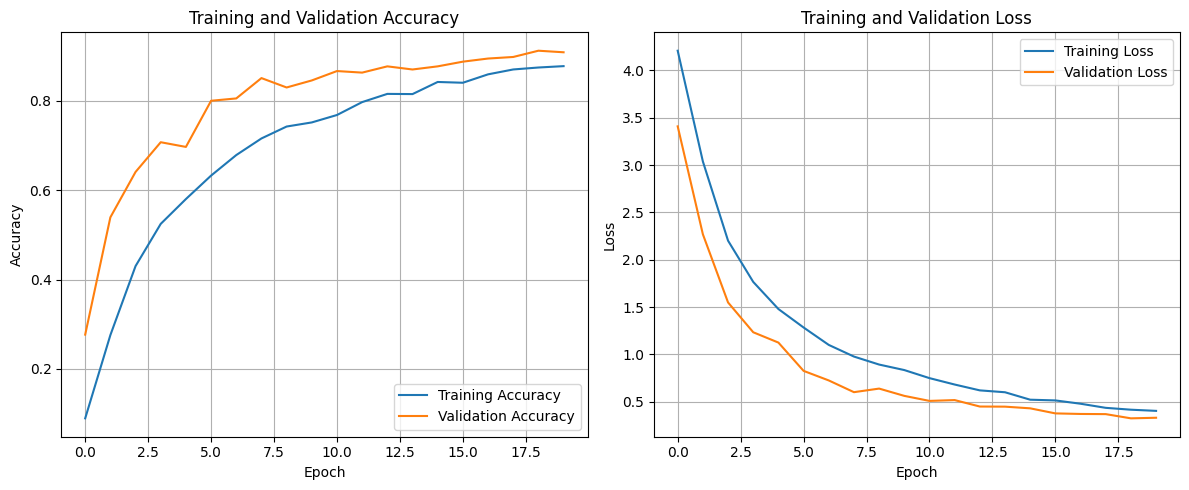


Training history plots displayed.


In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nTraining history plots displayed.")